In [1]:
# parameters

signal = "mom12-1m-a"
gate = "mom12m-andor-6m"

interval_days= "30"
max_long = "4"
max_short = "1"

show = "True"

In [2]:
interval_days_p = int(interval_days)
max_long_p = int(max_long)
max_short_p = int(max_short)
show_p = show.lower() == "true"

In [3]:
import polars as pl
import datetime as dt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import scrapbook as sb

signals_map = {
    "mom12m": pl.col("mom12m"),
    "mom1m": pl.col("mom1m"),
    "mom2m": pl.col("mom2m"),
    "mom3m": pl.col("mom3m"),
    "mom6m": pl.col("mom6m"),
    "mom12-1m-a": pl.col("mom12m") - pl.col("mom1m"),
    "mom12-1m-b": pl.col("mom11m").shift(30).over("symbol"),
}
signal_expr = signals_map[signal]

gates_map = {
    "mom12m-andor-6m": [
        (pl.col("mom12m") > 0) | (pl.col("mom6m") > 0),
        (pl.col("mom12m") < 0) & (pl.col("mom6m") < 0),
    ],
    "ema50d": [
        pl.col("ema50d") < pl.col("close"),
        pl.col("ema50d") > pl.col("close"),
    ],
}
gate_expr = gates_map[gate]

df = (
    pl.read_parquet('stables-1d.parquet')
    .select(
        date=pl.col('ts').dt.date(),
        symbol=pl.col('symbol').str.strip_suffix('USDT'),
        close=pl.col('close'),
        volume=pl.col('quote_volume'),
    )
    .filter(pl.col('symbol').is_in(['USDC','USDT','BUSD','TUSD','PAXG','UST','LUNA']).not_())
    .sort(['symbol','date'])
    .with_columns(**{
            f"mom{n}m": pl.col("close").pct_change(30 * n).over("symbol")
            for n in [1, 2, 3, 6, 11, 12]
        },
        sma50d=pl.col("close").rolling_mean(50).over("symbol"),
        ema50d=pl.col("close").ewm_mean(span=50, adjust=True).over("symbol"),
    )
    .with_columns(score=signal_expr)
    .with_columns(
        long_rank=pl.when(gate_expr[0])
        .then(
            pl.col("score").rank(descending=True).over("date") / pl.len().over("date")
        )
        .otherwise(None),
        short_rank=pl.when(gate_expr[1])
        .then(
            pl.col("score").rank(descending=False).over("date") / pl.len().over("date")
        )
        .otherwise(None),
        daily_ret=pl.col("close").pct_change().over("symbol"),
    )
)
df

date,symbol,close,volume,mom1m,mom2m,mom3m,mom6m,mom11m,mom12m,sma50d,ema50d,score,long_rank,short_rank,daily_ret
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-09-22,"""0G""",4.839,3.4369e8,null,null,null,null,null,null,null,4.839,null,null,null,null
2025-09-23,"""0G""",5.815,3.0494e8,null,null,null,null,null,null,null,5.33676,null,null,null,0.201695
2025-09-24,"""0G""",5.005,1.0226e8,null,null,null,null,null,null,null,5.221721,null,null,null,-0.139295
2025-09-25,"""0G""",3.917,5.3643e7,null,null,null,null,null,null,null,4.875714,null,null,null,-0.217383
2025-09-26,"""0G""",3.679,5.6700e7,null,null,null,null,null,null,null,4.616849,null,null,null,-0.060761
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-04-12,"""币安人生""",0.1781,4.5356e7,1.938944,0.872766,0.277618,null,null,null,0.06556,0.077363,null,null,null,0.270328
2026-04-13,"""币安人生""",0.2068,1.1307e8,2.463987,1.078392,0.198146,null,null,null,0.067976,0.08256,null,null,null,0.161145
2026-04-14,"""币安人生""",0.3437,1.9899e8,4.552504,2.379548,1.288282,null,null,null,0.073072,0.093035,null,null,null,0.661992


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3165/3165 [00:02<00:00, 1579.95it/s]


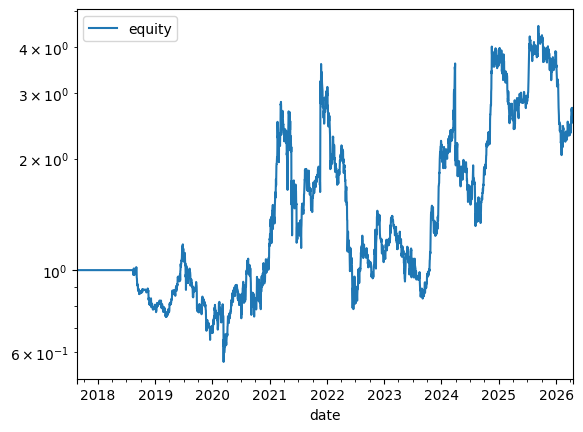

Final Equity: 2.57
CAGR: 11.48%
Max Drawdown: -78.19%
Sortino: 0.63


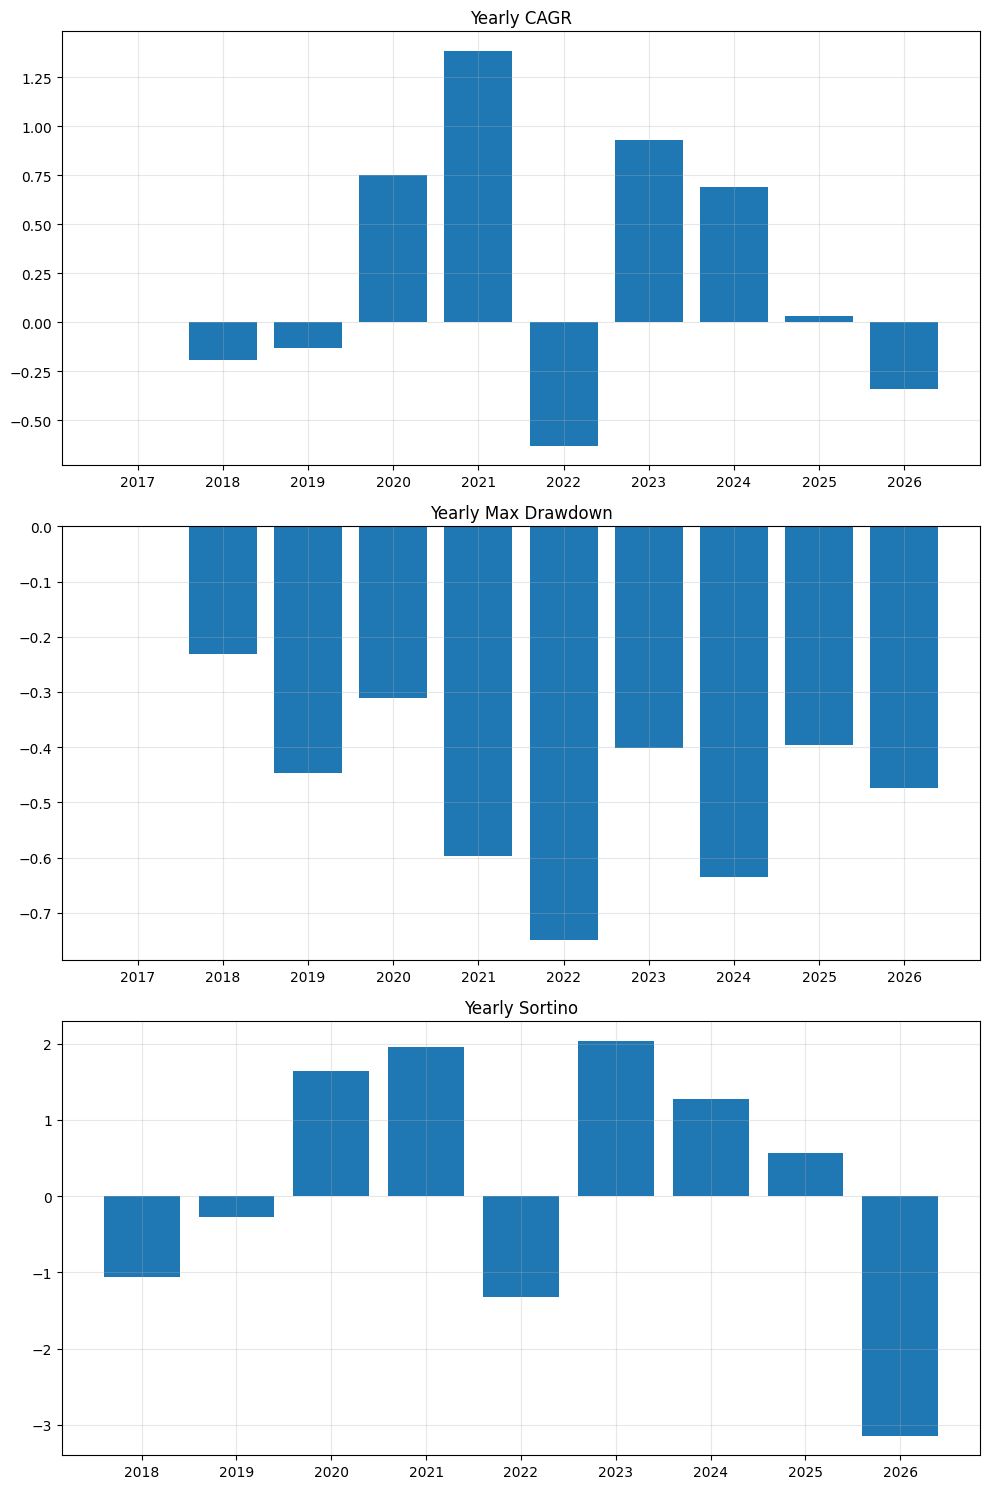

In [4]:
n_slots = max_long_p + max_short_p

res_frag = []
folio_long = []
folio_short = []
last_rebalance = dt.date(1970, 1, 1)

dates = df['date'].unique().sort().to_list()
for now in tqdm(dates):
    dfnow = df.filter(pl.col('date') == now)
        
    # Calculate daily return from existing portfolio
    long_rets = dfnow.filter(pl.col('symbol').is_in(folio_long))['daily_ret'].to_list()
    short_rets = [-r for r in dfnow.filter(pl.col('symbol').is_in(folio_short))['daily_ret'].to_list() if r is not None]
    
    # Simple average return across all slots (treating missing slots as cash)
    daily_portfolio_ret = (sum(long_rets) + sum(short_rets)) / n_slots if n_slots > 0 else 0.0
    
    res_frag.append(pl.DataFrame({
        'date': [now],
        'daily_ret': [daily_portfolio_ret]
    }))

    # Rebalance at end of day
    if now - last_rebalance >= dt.timedelta(days=interval_days_p):
        # Pick new folio for tomorrow
        folio_long = dfnow.drop_nulls('long_rank').sort('long_rank', descending=False)[:max_long_p]['symbol'].to_list()
        folio_short = dfnow.drop_nulls('short_rank').sort('short_rank', descending=False)[:max_short_p]['symbol'].to_list()
        last_rebalance = now

res = (
    pl.concat(res_frag)
    .sort('date')
    .with_columns(
        equity=(pl.col('daily_ret') + 1).log().cum_sum().exp(),
    )
)
if show_p:
    res.to_pandas().plot(x='date',y='equity',logy=True)
    plt.show()

# Print metrics
final_equity = res['equity'][-1]
days = (res['date'][-1] - res['date'][0]).days
cagr = final_equity ** (365/days) - 1

# Max Drawdown
res = res.with_columns(
    rolling_max=pl.col('equity').cum_max(),
)
res = res.with_columns(
    drawdown=(pl.col('equity') - pl.col('rolling_max')) / pl.col('rolling_max')
)
max_dd = res['drawdown'].min()

# Sortino Ratio (Annualized)
downside_returns = res.filter(pl.col('daily_ret') < 0)['daily_ret']
downside_deviation = (downside_returns.std() or np.nan) * np.sqrt(365)
sortino = (res['daily_ret'].mean() * 365) / downside_deviation if downside_deviation > 0 else 0

if show_p:
    print(f"Final Equity: {final_equity:.2f}")
    print(f"CAGR: {cagr:.2%}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print(f"Sortino: {sortino:.2f}")

# Scrapbook exports
sb.glue("final_equity", float(final_equity))
sb.glue("cagr", float(cagr))
sb.glue("max_drawdown", float(max_dd))
sb.glue("sortino", float(sortino))

# Yearly Metrics
yearly_res = (
    res.with_columns(year=pl.col('date').dt.year())
    .group_by('year')
    .agg(
        final_eq=pl.col('equity').last(),
        start_eq=pl.col('equity').first(),
        ann_ret=(pl.col('daily_ret').mean() * 365),
        downside_std=(pl.col('daily_ret').filter(pl.col('daily_ret') < 0).std() * np.sqrt(365)),
        max_dd=( (pl.col('equity') - pl.col('equity').cum_max()) / pl.col('equity').cum_max() ).min()
    )
    .with_columns(
        cagr=(pl.col('final_eq') / pl.col('start_eq')) - 1, # Simple annual return for the year
        sortino=pl.col('ann_ret') / pl.col('downside_std')
    )
    .sort('year')
)

if show_p:
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    metrics = [('cagr', 'CAGR'), ('max_dd', 'Max Drawdown'), ('sortino', 'Sortino')]
    
    for i, (col, title) in enumerate(metrics):
        yearly_pd = yearly_res.to_pandas()
        axes[i].bar(yearly_pd['year'].astype(str), yearly_pd[col])
        axes[i].set_title(f'Yearly {title}')
        axes[i].grid(True, alpha=0.3)
        if col == 'max_dd':
            axes[i].set_ylim(None, 0)
    
    plt.tight_layout()
    plt.show()

raise ValueError("skip")
from scipy.optimize import brute

interval_map = [7, 14, 30, 60]

def objective(params, df):
    interval_sel, max_long_p, max_short_p = params
    interval_days_p = interval_map[interval_sel]
    res = evaluate(run_backtest(df, interval_days_p, max_long_p, max_short_p), show=False)

    return -res['sortino']

if __name__ == "__main__":
    ranges = (slice(0, 4, 1), slice(1, 10, 1), slice(1, 10, 1))
    _, _, grid, Jout = brute(objective, ranges, args=(df,), finish=None, full_output=True, workers=10)
    
    flat_indices = np.argsort(Jout.flatten())
    multi_indices = [np.unravel_index(idx, Jout.shape) for idx in flat_indices]
    opt_frag = []
    for i, idx in enumerate(multi_indices):
        params = [grid[d][idx] for d in range(len(ranges))]
        score = Jout[idx]
        opt_frag.append(pl.DataFrame({
            'sortino': -score,
            'holding_days': interval_map[params[0]],
            'max_long':params[1],
            'max_short':params[2],
        }))
    
    opt = pl.concat(opt_frag)
    opt.write_parquet('opt.parquet')
    print(opt.sort('sortino', descending=True))